# Article — calibration de $E_i$ en probabilité de stress $\xi_{emp}$

On transforme l'**énergie de corrélation** $E_i(t)$ (moyenne des $|C_{ij}|$ de
l'actif $i$ ce jour-là, $\in[0,1]$ mais **pas** une probabilité) en une vraie
probabilité, pour la comparer à $x_i^{SIS}(t)\in[0,1]$ qui, lui, *est* une
probabilité (« actif infecté »).

**Recette** (fonctions dans [`code/proxy.py`](../code/proxy.py)) :

1. Indicateur de stress indépendant, par actif :
$I_i(t) = \mathbf{1}(|r_i(t)| > q_i^{90})$, où $q_i^{90}$ est le 90ᵉ centile de
$|r_i|$ (⇒ $\sim\!10\%$ de $I=1$ par actif).
2. Toutes les paires $(E_i(t), I_i(t))$ sur les $N$ actifs $\times$ jours.
3. Calibration : $\xi_{emp}(E\text{-bin}) = P(I=1 \mid E \in \text{bin}) =
\#\{I=1\}/\#\{\text{obs}\}$ dans le bin (dénominateur = effectif du bin).
4. $f : E \mapsto P(\text{stress}\mid E)$ (isotonique/logistique) ⇒
$\xi_{emp}(t)=f(E_i(t))$, comparable à $x_i^{SIS}(t)$.

Ce notebook **consomme** `code/proxy.py` et le pipeline SIS existant
(`data`, `pipeline`, `sis`).

In [1]:
import sys
sys.path.insert(0, '../code')
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr

from data import build_context
import pipeline, sis, config, proxy

ctx = build_context()          # données + base (E_daily_all) + matrices A (cache)

N = 146 actifs, T = 13360 obs ; 2019-04-01 10:00:00 -> 2023-05-03 15:30:00
[cache] OK  base
1031 jours ; <|C_ij|> moyen = 0.4686


## 1. Indicateur $I_i$, paires $(E_i, I_i)$ et mapping $f$

Tout est fait par `proxy.build_mapping` : rendements journaliers, indicateur
extrême par actif, paires, courbe de calibration, et les fonctions isotonique /
logistique.

In [2]:
mp = proxy.build_mapping(ctx, q=0.90, kind='isotonic')
print(f"{mp.Ev.size} paires (E_i, I_i) ; {int(mp.Iv.sum())} extrêmes")
print(f"P(I=1) marginal = {mp.marginal:.4f}  (attendu ~0.10)")

150526 paires (E_i, I_i) ; 15038 extrêmes
P(I=1) marginal = 0.0999  (attendu ~0.10)


## 2. Courbe de calibration $\xi_{emp}(E\text{-bin}) = P(I=1\mid E\text{-bin})$

xi_emp franchit le marginal (0.10) en E* = 0.510


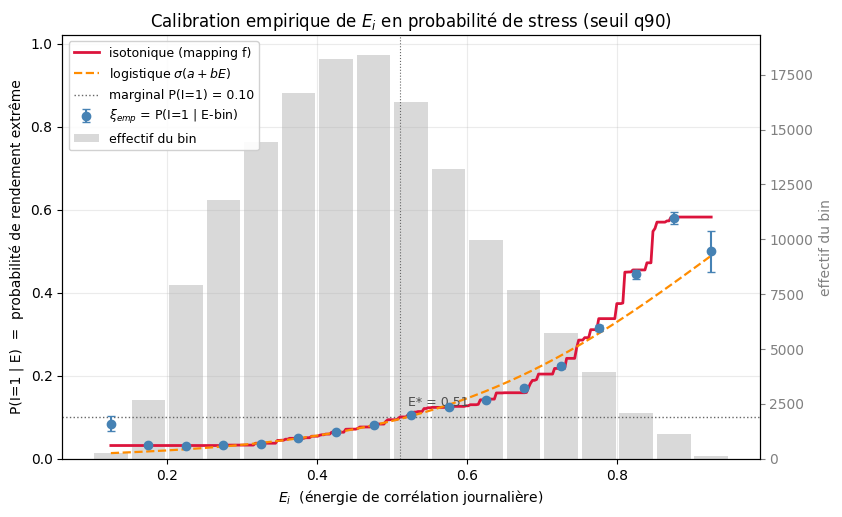

In [3]:
cur  = mp.curve
grid = np.linspace(cur['centers'].min(), cur['centers'].max(), 300)
E_star = proxy.crossing(grid, mp.iso(grid), mp.marginal)
print(f"xi_emp franchit le marginal ({mp.marginal:.2f}) en E* = {E_star:.3f}")

fig, ax = plt.subplots(figsize=(9, 5.5))
axb = ax.twinx()
axb.bar(cur['centers'], cur['n'], width=0.045, color='0.85', zorder=0, label='effectif du bin')
axb.set_ylabel('effectif du bin', color='0.5'); axb.tick_params(axis='y', colors='0.5')
axb.set_zorder(0); ax.set_zorder(1); ax.patch.set_visible(False)

ax.errorbar(cur['centers'], cur['p'], yerr=cur['se'], fmt='o', ms=6, color='steelblue',
            ecolor='steelblue', capsize=3, zorder=4, label=r'$\xi_{emp}$ = P(I=1 | E-bin)')
ax.plot(grid, mp.iso(grid), color='crimson', lw=2, zorder=3, label='isotonique (mapping f)')
ax.plot(grid, mp.log(grid), color='darkorange', lw=1.6, ls='--', zorder=3,
        label=r'logistique $\sigma(a+bE)$')
ax.axhline(mp.marginal, color='0.4', lw=1, ls=':', zorder=2,
           label=f'marginal P(I=1) = {mp.marginal:.2f}')
if E_star is not None:
    ax.axvline(E_star, color='0.4', lw=0.8, ls=':', zorder=2)
    ax.annotate(f'E* = {E_star:.2f}', (E_star, mp.marginal), textcoords='offset points',
                xytext=(6, 8), fontsize=9, color='0.3')

ax.set_xlabel(r'$E_i$  (énergie de corrélation journalière)')
ax.set_ylabel(r'P(I=1 | E)  =  probabilité de rendement extrême')
ax.set_title(r'Calibration empirique de $E_i$ en probabilité de stress (seuil q90)')
ax.set_ylim(0, max(1.0, cur['p'].max() + cur['se'].max()) * 1.02); ax.grid(alpha=0.25)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9, framealpha=0.9)
plt.show()

**Lecture.** Courbe **monotone croissante** ($\sim\!3\%$ → $\sim\!58\%$), croise
le marginal $P(I=1)=0.10$ en $E^\*\approx0.51$. $E_i$ prédit donc le rendement
extrême, et $f$ le transforme en probabilité exploitable.

## 3. Section dynamique — $x_i^{SIS}(t)$ vs $\xi_{emp}(t)=f(E_i(t))$

Pipeline SIS **inchangé** (`pipeline.load_periods`, `sis.cache_signed`,
`sis.integrate_fast`). On garde l'actif au meilleur $R^2(x^{SIS}, E_i)$ parmi les
crises $\geq 30$ jours, puis on superpose les **deux probabilités**.

In [4]:
P  = pipeline.load_periods(ctx)
fc = sis.make_fit_context(ctx, P['crisis_map'])
A  = ctx.A_sis['PMFG']

best = None   # (r2, pa, pb, gi, E_i, xt)
for (pa, pb) in P['intervals_chrono']:
    if pb - pa + 1 < 30:
        continue
    cache = sis.cache_signed(pa, pb, fc)
    for gi, d in cache.items():
        E_i = d['E_i']; okk = ~np.isnan(E_i)
        if okk.sum() < 5:
            continue
        xt = sis.integrate_fast(d, gi, A)
        r2 = linregress(E_i[okk], xt[okk]).rvalue ** 2
        if best is None or r2 > best[0]:
            best = (r2, pa, pb, gi, E_i, xt)

r2, pa, pb, gi, E_i, xt = best
name   = ctx.asset_names[gi]
xi_emp = proxy.map_energy(E_i, mp.f)
okk    = ~np.isnan(E_i)
r_se = pearsonr(xt[okk], xi_emp[okk])[0]
r_sE = pearsonr(xt[okk], E_i[okk])[0]
print(f"Actif '{name}' — PMFG — {ctx.all_days[pa]} -> {ctx.all_days[pb]}")
print(f"  R2(x_SIS, E_i)       = {r2:.3f}")
print(f"  r(x_SIS, xi_emp)     = {r_se:.3f}")
print(f"  r(x_SIS, E_i) (réf.) = {r_sE:.3f}")
print(f"  E_i in [{np.nanmin(E_i):.2f}, {np.nanmax(E_i):.2f}] -> "
      f"xi_emp in [{np.nanmin(xi_emp):.2f}, {np.nanmax(xi_emp):.2f}]")

[cache] OK  crisis_map


Actif 'AMZN' — PMFG — 2019-04-01 -> 2019-05-13
  R2(x_SIS, E_i)       = 0.894
  r(x_SIS, xi_emp)     = 0.715
  r(x_SIS, E_i) (réf.) = 0.945
  E_i in [0.00, 0.83] -> xi_emp in [0.00, 0.45]


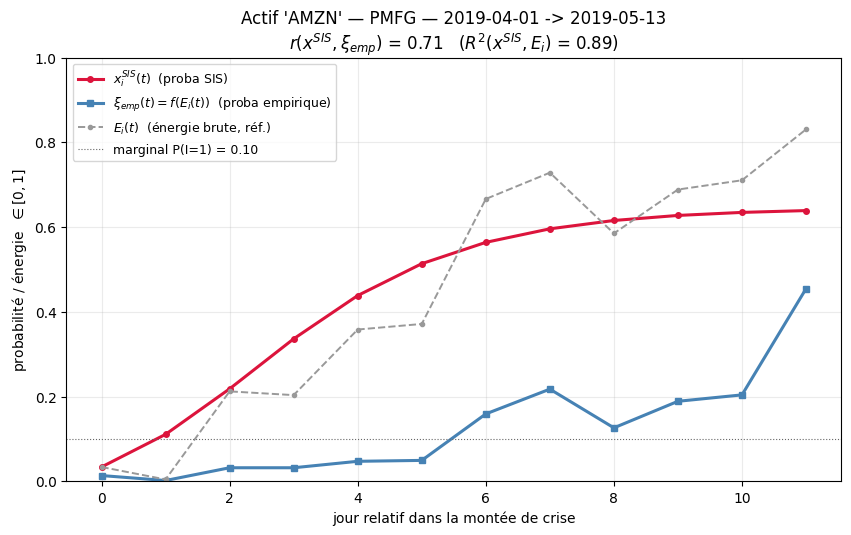

In [5]:
t = np.arange(len(E_i))
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(t, xt, color='crimson', lw=2.2, marker='o', ms=4, label=r'$x_i^{SIS}(t)$  (proba SIS)')
ax.plot(t, xi_emp, color='steelblue', lw=2.2, marker='s', ms=4,
        label=r'$\xi_{emp}(t)=f(E_i(t))$  (proba empirique)')
ax.plot(t, E_i, color='0.6', lw=1.4, ls='--', marker='.', ms=6,
        label=r'$E_i(t)$  (énergie brute, réf.)')
ax.axhline(mp.marginal, color='0.4', lw=0.8, ls=':', label=f'marginal P(I=1) = {mp.marginal:.2f}')
ax.set_xlabel('jour relatif dans la montée de crise')
ax.set_ylabel(r'probabilité / énergie  $\in [0, 1]$')
ax.set_title(f"Actif '{name}' — PMFG — {ctx.all_days[pa]} -> {ctx.all_days[pb]}\n"
             fr"$r(x^{{SIS}},\xi_{{emp}})$ = {r_se:.2f}   ($R^2(x^{{SIS}},E_i)$ = {r2:.2f})")
ax.set_ylim(0, 1); ax.grid(alpha=0.25); ax.legend(loc='best', fontsize=9)
plt.show()

## Conclusion

- **Même échelle** : $x_i^{SIS}(t)$ et $\xi_{emp}(t)$ sont deux probabilités
  $\in[0,1]$ ⇒ superposition **légitime** (pas le cas avec $E_i$ brute).
- **Fait honnête** : le SIS **surestime** le niveau de stress ; le mapping non
  linéaire baisse aussi la corrélation de forme ($r(x^{SIS},\xi_{emp}) <
  r(x^{SIS},E_i)$). Comme $f$ est monotone, les **rangs** (donc la sélection
  $R^2>0.6$) sont inchangés : $\xi_{emp}$ légitime les unités, sans modifier le
  fond de l'analyse.
- **Réutilisation** : `proxy.map_energy(E_i, mp.f)` remplace $E_i$ par une
  probabilité partout dans le pipeline. Passer `kind='logistic'` pour la version lisse.